In [ ]:
# 1 Install & Imports
!pip install torch --quiet

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import torch
import torch.nn as nn

print("PyTorch version:", torch.__version__)
print("All imports OK")

PyTorch version: 2.10.0+cpu
All imports OK


In [ ]:
# 2 Loading in the log file

LOG_PATH = "sample_pg.log"

with open(LOG_PATH, "r", encoding="utf-8") as f:
    lines = f.readlines()

print("Total raw lines:", len(lines))
lines[:3]

Total raw lines: 1679


["2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | SELECT | products | SUCCESS | 1 | 10 | SELECT COUNT(*) FROM products WHERE category = 'home';\n",
 '2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | UPDATE | products | SUCCESS | 1 | 2 | UPDATE products SET stock = 1 WHERE product_id = 26;\n',
 "2026-04-09 17:13:39 | app_user | employee | s1 | 10.0.0.12 | desktop | prod | public | UPDATE | customers | SUCCESS | 1 | 2 | UPDATE customers SET last_login = '2026-04-03' WHERE customer_id = 179;\n"]

In [ ]:
# 3 parsing in log lines

rows = []

for line in lines:
    line = line.strip()
    if not line:
        continue
    parts = [p.strip() for p in line.split("|", 13)]
    if len(parts) != 14:
        print("Skipping malformed line:", line)
        continue
    rows.append(parts)

columns = [
    "timestamp", "user", "role", "session_id", "ip", "device",
    "database", "schema", "query_type", "table_name", "status",
    "rows_returned", "duration_ms", "sql"
]

df = pd.DataFrame(rows, columns=columns)
print("Parsed events:", len(df))
df.head()

Parsed events: 1617


,timestamp,user,role,session_id,ip,device,database,schema,query_type,table_name,status,rows_returned,duration_ms,sql
0,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,products,SUCCESS,1,10,SELECT COUNT(*) FROM products WHERE category =...
1,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,products,SUCCESS,1,2,UPDATE products SET stock = 1 WHERE product_id...
2,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,customers,SUCCESS,1,2,UPDATE customers SET last_login = '2026-04-03'...
3,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,INSERT,customers,SUCCESS,1,2,"INSERT INTO customers (name, city, email, stat..."
4,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,orders,SUCCESS,125,1,SELECT * FROM orders WHERE status = 'shipped';


In [ ]:
# 4 cleaning the datatypes

df["timestamp"]    = pd.to_datetime(df["timestamp"])
df["rows_returned"] = df["rows_returned"].astype(int)
df["duration_ms"]  = df["duration_ms"].astype(int)
df = df.sort_values(["session_id", "timestamp"]).reset_index(drop=True)

print(df.shape)
df.dtypes

(1617, 14)


,0
timestamp,datetime64[ns]
user,object
role,object
session_id,object
ip,object
device,object
database,object
schema,object
query_type,object
table_name,object


In [ ]:
# normalize sql template

def normalize_sql(sql):
    sql = sql.strip().rstrip(";")
    sql = re.sub(r"'[^']*'", "?", sql)
    sql = re.sub(r"\b\d+(\.\d+)?\b", "?", sql)
    sql = re.sub(r"\s+", " ", sql).strip()
    return sql

df["template"] = df["sql"].apply(normalize_sql)
df[["sql", "template"]].head(10)

,sql,template
0,SELECT COUNT(*) FROM products WHERE category =...,SELECT COUNT(*) FROM products WHERE category = ?
1,UPDATE products SET stock = 1 WHERE product_id...,UPDATE products SET stock = ? WHERE product_id...
2,UPDATE customers SET last_login = '2026-04-03'...,UPDATE customers SET last_login = ? WHERE cust...
3,"INSERT INTO customers (name, city, email, stat...","INSERT INTO customers (name, city, email, stat..."
4,SELECT * FROM orders WHERE status = 'shipped';,SELECT * FROM orders WHERE status = ?
5,"SELECT name, price FROM products WHERE product...","SELECT name, price FROM products WHERE product..."
6,"SELECT name, email FROM customers WHERE custom...","SELECT name, email FROM customers WHERE custom..."
7,"INSERT INTO orders (customer_id, total, status...","INSERT INTO orders (customer_id, total, status..."
8,SELECT COUNT(*) FROM customers WHERE status = ...,SELECT COUNT(*) FROM customers WHERE status = ?
9,UPDATE customers SET city = 'Riverside' WHERE ...,UPDATE customers SET city = ? WHERE customer_i...


In [ ]:
# 6 creating template IDs

template_vocab = {tpl: i for i, tpl in enumerate(df["template"].unique())}
df["template_id"] = df["template"].map(template_vocab)

print("Unique templates:", len(template_vocab))
df[["template", "template_id"]].drop_duplicates().sort_values("template_id")

Unique templates: 41


,template,template_id
0,SELECT COUNT(*) FROM products WHERE category = ?,0
1,UPDATE products SET stock = ? WHERE product_id...,1
2,UPDATE customers SET last_login = ? WHERE cust...,2
3,"INSERT INTO customers (name, city, email, stat...",3
4,SELECT * FROM orders WHERE status = ?,4
5,"SELECT name, price FROM products WHERE product...",5
6,"SELECT name, email FROM customers WHERE custom...",6
7,"INSERT INTO orders (customer_id, total, status...",7
8,SELECT COUNT(*) FROM customers WHERE status = ?,8
9,UPDATE customers SET city = ? WHERE customer_i...,9


In [ ]:
# 7 timing the features

df["time_delta"] = (
    df.groupby("session_id")["timestamp"]
      .diff()
      .dt.total_seconds()
      .fillna(0)
      .astype(int)
)
df["position_in_session"] = df.groupby("session_id").cumcount() + 1

df[["session_id", "timestamp", "time_delta", "position_in_session"]].head(10)

,session_id,timestamp,time_delta,position_in_session
0,s1,2026-04-09 17:13:39,0,1
1,s1,2026-04-09 17:13:39,0,2
2,s1,2026-04-09 17:13:39,0,3
3,s1,2026-04-09 17:13:39,0,4
4,s1,2026-04-09 17:13:39,0,5
5,s1,2026-04-09 17:13:39,0,6
6,s1,2026-04-09 17:13:39,0,7
7,s1,2026-04-09 17:13:39,0,8
8,s1,2026-04-09 17:13:39,0,9
9,s1,2026-04-09 17:13:39,0,10


In [ ]:
# risk flag

def make_risk_flag(row):
    if row["query_type"] in {"GRANT", "ALTER", "DROP"}:
        return 1
    if row["schema"] in {"admin", "payroll"}:
        return 1
    if row["table_name"] in {"sensitive_payroll"}:
        return 1
    if row["status"] == "FAILED":
        return 1
    return 0

df["risk_flag"] = df.apply(make_risk_flag, axis=1)
df[["session_id", "query_type", "schema", "table_name", "status", "risk_flag"]].head(10)

,session_id,query_type,schema,table_name,status,risk_flag
0,s1,SELECT,public,products,SUCCESS,0
1,s1,UPDATE,public,products,SUCCESS,0
2,s1,UPDATE,public,customers,SUCCESS,0
3,s1,INSERT,public,customers,SUCCESS,0
4,s1,SELECT,public,orders,SUCCESS,0
5,s1,SELECT,public,products,SUCCESS,0
6,s1,SELECT,public,customers,SUCCESS,0
7,s1,INSERT,public,orders,SUCCESS,0
8,s1,SELECT,public,customers,SUCCESS,0
9,s1,UPDATE,public,customers,SUCCESS,0


In [ ]:
# encoding categoricals

def make_vocab(series):
    vals = sorted(series.astype(str).unique())
    return {v: i for i, v in enumerate(vals)}

user_vocab   = make_vocab(df["user"])
role_vocab   = make_vocab(df["role"])
ip_vocab     = make_vocab(df["ip"])
device_vocab = make_vocab(df["device"])
db_vocab     = make_vocab(df["database"])
schema_vocab = make_vocab(df["schema"])
query_vocab  = make_vocab(df["query_type"])
table_vocab  = make_vocab(df["table_name"])
status_vocab = make_vocab(df["status"])

df["user_id"]      = df["user"].map(user_vocab)
df["role_id"]      = df["role"].map(role_vocab)
df["ip_id"]        = df["ip"].map(ip_vocab)
df["device_id"]    = df["device"].map(device_vocab)
df["database_id"]  = df["database"].map(db_vocab)
df["schema_id"]    = df["schema"].map(schema_vocab)
df["query_type_id"] = df["query_type"].map(query_vocab)
df["table_id"]     = df["table_name"].map(table_vocab)
df["status_id"]    = df["status"].map(status_vocab)

df.head()

,timestamp,user,role,session_id,ip,device,database,schema,query_type,table_name,...,risk_flag,user_id,role_id,ip_id,device_id,database_id,schema_id,query_type_id,table_id,status_id
0,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,products,...,0,2,1,0,0,0,2,3,5,1
1,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,products,...,0,2,1,0,0,0,2,4,5,1
2,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,UPDATE,customers,...,0,2,1,0,0,0,2,4,1,1
3,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,INSERT,customers,...,0,2,1,0,0,0,2,2,1,1
4,2026-04-09 17:13:39,app_user,employee,s1,10.0.0.12,desktop,prod,public,SELECT,orders,...,0,2,1,0,0,0,2,3,3,1


In [ ]:
# selecting features

feature_cols = [
    "template_id", "user_id", "role_id", "ip_id", "device_id",
    "database_id", "schema_id", "query_type_id", "table_id", "status_id",
    "rows_returned", "duration_ms", "time_delta", "position_in_session", "risk_flag"
]

df_model = df[["session_id", "timestamp"] + feature_cols].copy()
print(f"Features: {len(feature_cols)}")
df_model.head()

Features: 15


,session_id,timestamp,template_id,user_id,role_id,ip_id,device_id,database_id,schema_id,query_type_id,table_id,status_id,rows_returned,duration_ms,time_delta,position_in_session,risk_flag
0,s1,2026-04-09 17:13:39,0,2,1,0,0,0,2,3,5,1,1,10,0,1,0
1,s1,2026-04-09 17:13:39,1,2,1,0,0,0,2,4,5,1,1,2,0,2,0
2,s1,2026-04-09 17:13:39,2,2,1,0,0,0,2,4,1,1,1,2,0,3,0
3,s1,2026-04-09 17:13:39,3,2,1,0,0,0,2,2,1,1,1,2,0,4,0
4,s1,2026-04-09 17:13:39,4,2,1,0,0,0,2,3,3,1,125,1,0,5,0


In [ ]:
# building session sequences

session_groups = df_model.groupby("session_id")
session_sequences = {}

for sid, group in session_groups:
    group = group.sort_values("timestamp")
    session_sequences[sid] = group[feature_cols].to_numpy(dtype=float)

print("Total sessions:", len(session_sequences))
for sid, seq in session_sequences.items():
    print(sid, seq.shape)

Total sessions: 62
s1 (20, 15)
s10 (42, 15)
s11 (46, 15)
s12 (22, 15)
s13 (19, 15)
s14 (45, 15)
s15 (46, 15)
s16 (13, 15)
s17 (24, 15)
s18 (43, 15)
s19 (30, 15)
s2 (35, 15)
s20 (16, 15)
s21 (37, 15)
s22 (21, 15)
s23 (33, 15)
s24 (50, 15)
s25 (30, 15)
s26 (22, 15)
s27 (20, 15)
s28 (49, 15)
s29 (16, 15)
s3 (32, 15)
s30 (32, 15)
s31 (41, 15)
s32 (7, 15)
s33 (15, 15)
s34 (40, 15)
s35 (6, 15)
s36 (32, 15)
s37 (49, 15)
s38 (22, 15)
s39 (6, 15)
s4 (49, 15)
s40 (25, 15)
s41 (14, 15)
s42 (44, 15)
s43 (28, 15)
s44 (22, 15)
s45 (49, 15)
s46 (6, 15)
s47 (46, 15)
s48 (39, 15)
s49 (37, 15)
s5 (23, 15)
s50 (31, 15)
s51 (7, 15)
s52 (12, 15)
s53 (13, 15)
s54 (7, 15)
s55 (11, 15)
s56 (7, 15)
s57 (14, 15)
s58 (12, 15)
s59 (9, 15)
s6 (13, 15)
s60 (13, 15)
s61 (12, 15)
s62 (14, 15)
s7 (49, 15)
s8 (43, 15)
s9 (7, 15)


In [ ]:
# 12 split normal / anomaly

normal_sessions  = [f"s{i}" for i in range(1, 51)]
anomaly_sessions = [f"s{i}" for i in range(51, 63)]

train_sequences = [session_sequences[s] for s in normal_sessions  if s in session_sequences]
test_sequences  = [session_sequences[s] for s in anomaly_sessions if s in session_sequences]

print("Train sessions:", len(train_sequences))
print("Test sessions: ", len(test_sequences))

Train sessions: 50
Test sessions:  12


In [ ]:
# 13 pad sequences & build Tensors

max_len      = max(seq.shape[0] for seq in session_sequences.values())
num_features = len(feature_cols)

def pad_sequence(seq, max_len):
    padded = np.zeros((max_len, seq.shape[1]))
    padded[:seq.shape[0], :] = seq
    return padded

X_train = np.array([pad_sequence(seq, max_len) for seq in train_sequences])
X_test  = np.array([pad_sequence(seq, max_len) for seq in test_sequences])

print("Train tensor:", X_train.shape)   # (50, 50, 15)
print("Test tensor: ", X_test.shape)    # (12, 50, 15)

Train tensor: (50, 50, 15)
Test tensor:  (12, 50, 15)


In [ ]:
# 14 normalize features (MinMaxScaler)

n_train, seq_len, n_feat = X_train.shape
n_test = X_test.shape[0]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
X_test_scaled  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(n_test, seq_len, n_feat)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)
print("Scaler fit on training data only — no data leakage.")

Train shape: (50, 50, 15)
Test shape:  (12, 50, 15)
Scaler fit on training data only — no data leakage.


In [ ]:
#15 LSTM Model

import torch
import torch.nn as nn

class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, latent_dim)
        self.act  = nn.Tanh()

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.lstm(x)     # h_n: (1, batch, hidden_dim)
        h = h_n.squeeze(0)             # (batch, hidden_dim)
        return self.act(self.fc(h))    # (batch, latent_dim)


class LSTMDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.fc      = nn.Linear(latent_dim, hidden_dim)
        self.act     = nn.Tanh()
        self.lstm    = nn.LSTM(hidden_dim, output_dim, num_layers=1, batch_first=True)

    def forward(self, z):
        # z: (batch, latent_dim)
        h = self.act(self.fc(z))                               # (batch, hidden_dim)
        h_repeated = h.unsqueeze(1).repeat(1, self.seq_len, 1) # (batch, seq_len, hidden_dim)
        out, _ = self.lstm(h_repeated)                         # (batch, seq_len, output_dim)
        return out


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=15, hidden_dim=32, latent_dim=8, seq_len=50):
        super().__init__()
        self.encoder = LSTMEncoder(input_dim, hidden_dim, latent_dim)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, seq_len)

    def forward(self, x):
        z     = self.encoder(x)
        recon = self.decoder(z)
        return recon

    def encode(self, x_np):
        """(seq_len, features) numpy -> (latent_dim,) numpy"""
        self.eval()
        with torch.no_grad():
            t = torch.FloatTensor(x_np).unsqueeze(0)
            z = self.encoder(t)
        return z.squeeze(0).numpy()

    def reconstruct(self, x_np):
        """(seq_len, features) numpy -> (seq_len, features) numpy"""
        self.eval()
        with torch.no_grad():
            t     = torch.FloatTensor(x_np).unsqueeze(0)
            recon = self(t)
        return recon.squeeze(0).numpy()


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = LSTMAutoencoder(input_dim=n_feat, hidden_dim=32, latent_dim=8, seq_len=seq_len).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device:               {DEVICE}")
print(f"Trainable parameters: {total_params:,}")
print(f"Input dim:            {n_feat}")
print(f"Hidden dim:           32")
print(f"Latent dim:           8")
print(f"Sequence length:      {seq_len}")
print()
print(model)

Device:               cpu
Trainable parameters: 9,764
Input dim:            15
Hidden dim:           32
Latent dim:           8
Sequence length:      50

LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(15, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=8, bias=True)
    (act): Tanh()
  )
  (decoder): LSTMDecoder(
    (fc): Linear(in_features=8, out_features=32, bias=True)
    (act): Tanh()
    (lstm): LSTM(32, 15, batch_first=True)
  )
)


In [ ]:
# 16 training the LSTM autoencoder

X_train_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)  # (50, 50, 15)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS     = 300
all_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    recon = model(X_train_tensor)
    loss  = criterion(recon, X_train_tensor)
    loss.backward()
    optimizer.step()
    all_losses.append(loss.item())

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  |  Loss: {loss.item():.6f}")

model.eval()
print(f"\nFinal loss:      {all_losses[-1]:.6f}")
print(f"Starting loss:   {all_losses[0]:.6f}")
print(f"Loss reduction:  {(1 - all_losses[-1]/all_losses[0])*100:.1f}%")

Epoch   1/300  |  Loss: 0.260860
Epoch  50/300  |  Loss: 0.138426
Epoch 100/300  |  Loss: 0.087266
Epoch 150/300  |  Loss: 0.083037
Epoch 200/300  |  Loss: 0.081506
Epoch 250/300  |  Loss: 0.079151
Epoch 300/300  |  Loss: 0.073812

Final loss:      0.073812
Starting loss:   0.260860
Loss reduction:  71.7%


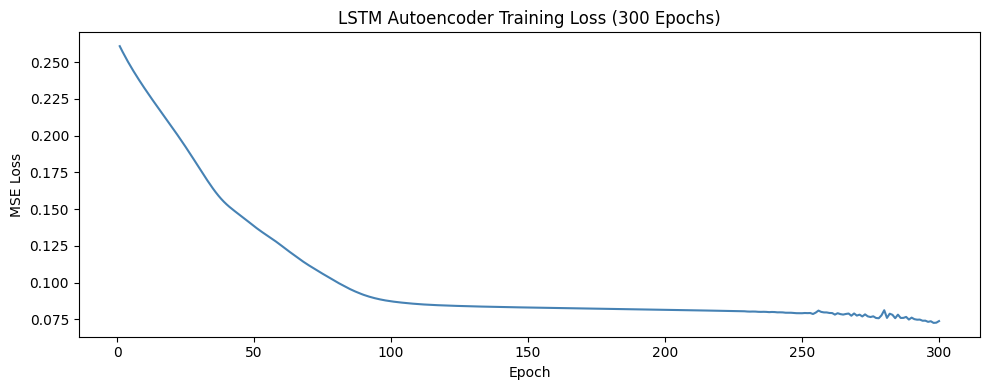

Saved: training_loss_lstm.png


In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(all_losses) + 1), all_losses, color='steelblue', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"LSTM Autoencoder Training Loss ({EPOCHS} Epochs)")
plt.tight_layout()
plt.savefig("training_loss_lstm.png", dpi=150)
plt.show()
print("Saved: training_loss_lstm.png")

In [ ]:
# 18 Reconstruction Error Scoring (Experiment 1).

all_data        = np.concatenate([X_train_scaled, X_test_scaled], axis=0)
all_labels      = ['normal'] * len(X_train_scaled) + ['anomaly'] * len(X_test_scaled)
all_session_ids = [f"s{i}" for i in range(1, 51)] + [f"s{i}" for i in range(51, 63)]

recon_errors = []
for x in all_data:
    recon = model.reconstruct(x)
    mse   = ((recon - x) ** 2).mean()
    recon_errors.append(mse)

recon_errors  = np.array(recon_errors)
normal_errors = recon_errors[:50]
threshold     = normal_errors.mean() + 2 * normal_errors.std()

print(f"Normal error mean:      {normal_errors.mean():.6f}")
print(f"Normal error std:       {normal_errors.std():.6f}")
print(f"Threshold (mean+2*std): {threshold:.6f}")

flagged = sum(1 for e in recon_errors[50:] if e > threshold)
print(f"\nAnomalies caught: {flagged}/12")

print("\nAnomaly session errors:")
for i, sid in enumerate(all_session_ids[50:]):
    err  = recon_errors[50 + i]
    flag = "FLAGGED" if err > threshold else "missed"
    print(f"  {sid}: {err:.6f}  [{flag}]")

Normal error mean:      0.071956
Normal error std:       0.021641
Threshold (mean+2*std): 0.115238

Anomalies caught: 10/12

Anomaly session errors:
  s51: 0.064249  [missed]
  s52: 0.115659  [FLAGGED]
  s53: 0.242280  [FLAGGED]
  s54: 0.073861  [missed]
  s55: 0.123794  [FLAGGED]
  s56: 0.138086  [FLAGGED]
  s57: 0.222417  [FLAGGED]
  s58: 0.123339  [FLAGGED]
  s59: 0.175660  [FLAGGED]
  s60: 0.215787  [FLAGGED]
  s61: 0.198373  [FLAGGED]
  s62: 0.129969  [FLAGGED]


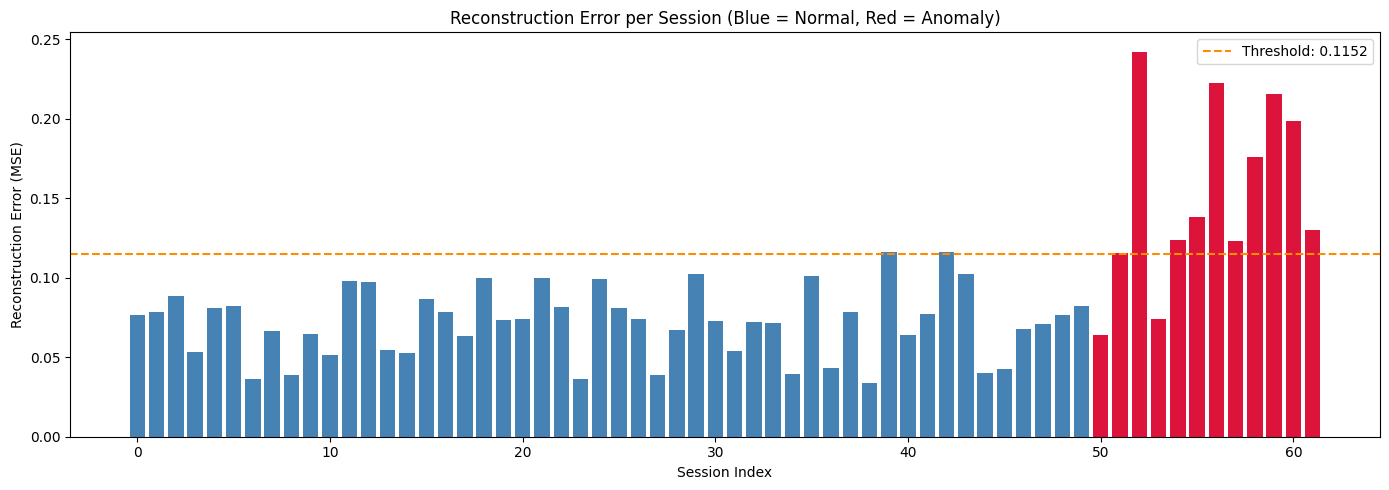

In [ ]:
colors = ['steelblue' if lab == 'normal' else 'crimson' for lab in all_labels]

plt.figure(figsize=(14, 5))
plt.bar(range(len(recon_errors)), recon_errors, color=colors, edgecolor='none')
plt.axhline(threshold, color='darkorange', linestyle='--', linewidth=1.5, label=f'Threshold: {threshold:.4f}')
plt.xlabel("Session Index")
plt.ylabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error per Session (Blue = Normal, Red = Anomaly)")
plt.legend()
plt.tight_layout()
plt.savefig("recon_error_bar_lstm.png", dpi=150)
plt.show()

In [ ]:
# Isolation Forest on raw embeddings

train_embeddings = np.array([model.encode(x) for x in X_train_scaled])
test_embeddings  = np.array([model.encode(x) for x in X_test_scaled])
all_embeddings   = np.concatenate([train_embeddings, test_embeddings], axis=0)

print(f"Embedding dim: {train_embeddings.shape[1]}")

iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_forest.fit(train_embeddings)

iso_scores = iso_forest.decision_function(all_embeddings)
iso_preds  = iso_forest.predict(all_embeddings)

print(f"\nNormal sessions falsely flagged: {sum(iso_preds[:50] == -1)}/50")
print(f"Anomalies caught:                {sum(iso_preds[50:] == -1)}/12")

print("\nAnomaly session scores:")
for i, sid in enumerate(all_session_ids[50:]):
    score = iso_scores[50 + i]
    pred  = "CAUGHT" if iso_preds[50 + i] == -1 else "missed"
    print(f"  {sid}: {score:.4f}  [{pred}]")

Embedding dim: 8

Normal sessions falsely flagged: 3/50
Anomalies caught:                0/12

Anomaly session scores:
  s51: 0.0261  [missed]
  s52: 0.0571  [missed]
  s53: 0.1553  [missed]
  s54: 0.0204  [missed]
  s55: 0.0512  [missed]
  s56: 0.0270  [missed]
  s57: 0.1634  [missed]
  s58: 0.0627  [missed]
  s59: 0.0587  [missed]
  s60: 0.1593  [missed]
  s61: 0.1581  [missed]
  s62: 0.1481  [missed]


Metric                         Recon Error Iso Forest
AUROC                               0.900      0.623
AUPR                                0.867      0.324
Recall @ 1% FPR                     0.750      0.000


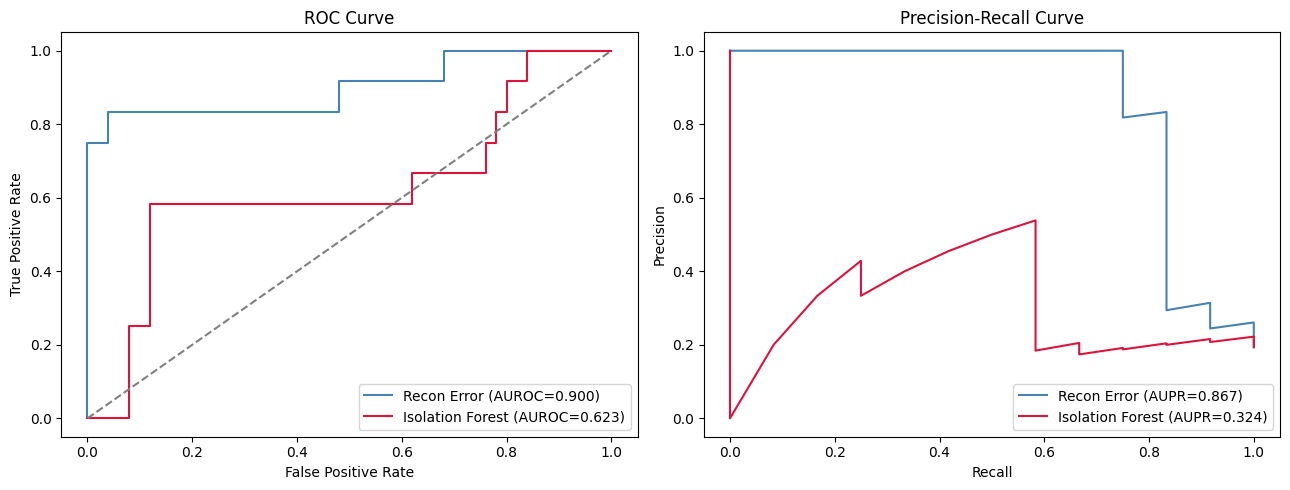

In [ ]:
# Evaluation Metrics + ROC/PR Curves
y_true = np.array([0] * 50 + [1] * 12)

auroc_recon = roc_auc_score(y_true, recon_errors)
aupr_recon  = average_precision_score(y_true, recon_errors)
auroc_iso   = roc_auc_score(y_true, -iso_scores)
aupr_iso    = average_precision_score(y_true, -iso_scores)

fpr_recon, tpr_recon, _ = roc_curve(y_true, recon_errors)
fpr_iso, tpr_iso, _     = roc_curve(y_true, -iso_scores)
prec_recon, rec_recon, _ = precision_recall_curve(y_true, recon_errors)
prec_iso, rec_iso, _     = precision_recall_curve(y_true, -iso_scores)

idx_recon = np.searchsorted(fpr_recon, 0.01)
idx_iso   = np.searchsorted(fpr_iso, 0.01)
recall_at_1_recon = tpr_recon[min(idx_recon, len(tpr_recon)-1)]
recall_at_1_iso   = tpr_iso[min(idx_iso, len(tpr_iso)-1)]

print("=" * 55)
print(f"{'Metric':<30} {'Recon Error':>10} {'Iso Forest':>10}")
print("=" * 55)
print(f"{'AUROC':<30} {auroc_recon:>10.3f} {auroc_iso:>10.3f}")
print(f"{'AUPR':<30} {aupr_recon:>10.3f} {aupr_iso:>10.3f}")
print(f"{'Recall @ 1% FPR':<30} {recall_at_1_recon:>10.3f} {recall_at_1_iso:>10.3f}")
print("=" * 55)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr_recon, tpr_recon, color='steelblue', label=f"Recon Error (AUROC={auroc_recon:.3f})")
ax1.plot(fpr_iso,   tpr_iso,   color='crimson',   label=f"Isolation Forest (AUROC={auroc_iso:.3f})")
ax1.plot([0,1],[0,1],'--',color='gray')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend()

ax2.plot(rec_recon, prec_recon, color='steelblue', label=f"Recon Error (AUPR={aupr_recon:.3f})")
ax2.plot(rec_iso,   prec_iso,   color='crimson',   label=f"Isolation Forest (AUPR={aupr_iso:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend()

plt.tight_layout()
plt.savefig("roc_pr_curves_lstm.png", dpi=150)
plt.show()

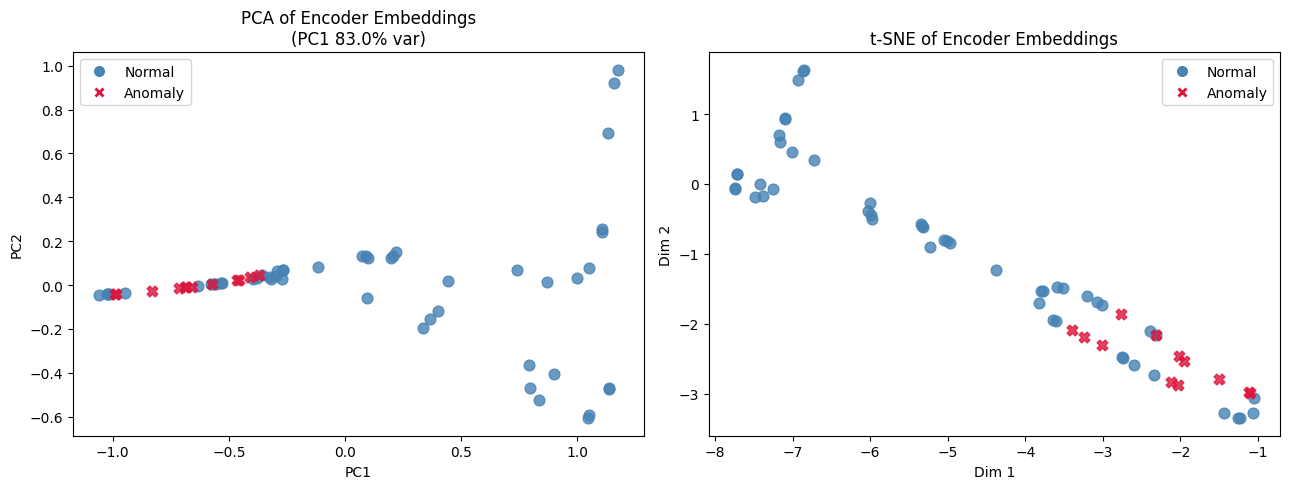

In [ ]:
#22 :  t-SNE/PCA Before Contrastive

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
colors_emb = ['steelblue' if lab == 'normal' else 'crimson' for lab in all_labels]
markers    = ['o' if lab == 'normal' else 'X' for lab in all_labels]

pca   = PCA(n_components=2, random_state=42)
emb2d = pca.fit_transform(all_embeddings)
for idx in range(len(all_embeddings)):
    ax1.scatter(emb2d[idx,0], emb2d[idx,1], c=colors_emb[idx], marker=markers[idx], s=60, alpha=0.8)
ax1.set_title(f"PCA of Encoder Embeddings\n(PC1 {pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2")

tsne  = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embeddings)-1))
emb2d_tsne = tsne.fit_transform(all_embeddings)
for idx in range(len(all_embeddings)):
    ax2.scatter(emb2d_tsne[idx,0], emb2d_tsne[idx,1], c=colors_emb[idx], marker=markers[idx], s=60, alpha=0.8)
ax2.set_title("t-SNE of Encoder Embeddings")
ax2.set_xlabel("Dim 1"); ax2.set_ylabel("Dim 2")

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',label='Normal',markersize=9),
                Line2D([0],[0],marker='X',color='w',markerfacecolor='crimson',label='Anomaly',markersize=9)]
ax1.legend(handles=legend_elems); ax2.legend(handles=legend_elems)
plt.tight_layout()
plt.savefig("tsne_pca_before_lstm.png", dpi=150)
plt.show()

In [ ]:
print(f"AUROC Recon Error: {auroc_recon:.3f}")
print(f"AUROC Iso Forest:  {auroc_iso:.3f}")
print(f"AUPR Recon Error:  {aupr_recon:.3f}")
print(f"AUPR Iso Forest:   {aupr_iso:.3f}")

AUROC Recon Error: 0.900
AUROC Iso Forest:  0.623
AUPR Recon Error:  0.867
AUPR Iso Forest:   0.324


In [ ]:
# Block 23 — Gentle Contrastive Pretraining
def augment_session(x, drop_rate=0.1, noise_std=0.05):
    aug = x.copy()
    aug += np.random.randn(*aug.shape) * noise_std
    mask = np.random.rand(*aug.shape) > drop_rate
    aug *= mask
    return aug

contrastive_optimizer = torch.optim.Adam(model.encoder.parameters(), lr=1e-4)
np.random.seed(42)
contrastive_losses = []
N_NEGATIVES = 5
CONTRASTIVE_EPOCHS = 50
TEMPERATURE = 1.0

print("Starting gentle contrastive pretraining...")
for epoch in range(1, CONTRASTIVE_EPOCHS + 1):
    epoch_loss = 0.0
    indices    = np.random.permutation(len(X_train_scaled))

    for i in indices:
        anchor   = X_train_scaled[i]
        positive = augment_session(anchor)

        neg_idx  = np.random.choice([j for j in range(len(X_train_scaled)) if j != i],
                                     size=N_NEGATIVES, replace=False)
        negatives = [X_train_scaled[j] for j in neg_idx]

        contrastive_optimizer.zero_grad()
        t_anchor   = torch.FloatTensor(anchor).unsqueeze(0).to(DEVICE)
        t_positive = torch.FloatTensor(positive).unsqueeze(0).to(DEVICE)
        t_negs     = torch.FloatTensor(np.stack(negatives)).to(DEVICE)

        z_a = model.encoder(t_anchor)
        z_p = model.encoder(t_positive)
        z_n = model.encoder(t_negs)

        z_a_norm = nn.functional.normalize(z_a, dim=1)
        z_p_norm = nn.functional.normalize(z_p, dim=1)
        z_n_norm = nn.functional.normalize(z_n, dim=1)

        pos_sim = (z_a_norm * z_p_norm).sum(dim=1) / TEMPERATURE
        neg_sim = (z_a_norm.unsqueeze(1) * z_n_norm.unsqueeze(0)).sum(dim=2) / TEMPERATURE
        logits  = torch.cat([pos_sim.unsqueeze(1), neg_sim.squeeze(0).unsqueeze(0)], dim=1)
        target  = torch.zeros(1, dtype=torch.long).to(DEVICE)
        pt_loss = nn.functional.cross_entropy(logits, target)
        pt_loss.backward()
        contrastive_optimizer.step()

        epoch_loss += pt_loss.item()

    avg_loss = epoch_loss / len(X_train_scaled)
    contrastive_losses.append(avg_loss)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3}/{CONTRASTIVE_EPOCHS}  |  InfoNCE Loss: {avg_loss:.4f}")

model.eval()
print("\nGentle contrastive pretraining complete.")

Starting gentle contrastive pretraining...
  Epoch   1/50  |  InfoNCE Loss: 1.6223
  Epoch  10/50  |  InfoNCE Loss: 1.2230
  Epoch  20/50  |  InfoNCE Loss: 1.2360
  Epoch  30/50  |  InfoNCE Loss: 1.1795
  Epoch  40/50  |  InfoNCE Loss: 1.1090
  Epoch  50/50  |  InfoNCE Loss: 1.1690

Gentle contrastive pretraining complete.


In [ ]:
# 24 — Isolation Forest re-evaluation on post-contrastive embeddings
train_emb_post = np.array([model.encode(x) for x in X_train_scaled])
test_emb_post  = np.array([model.encode(x) for x in X_test_scaled])
all_emb_post   = np.concatenate([train_emb_post, test_emb_post], axis=0)

iso_post   = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso_post.fit(train_emb_post)
iso_scores_post = iso_post.decision_function(all_emb_post)
iso_preds_post  = iso_post.predict(all_emb_post)

auroc_post = roc_auc_score(y_true, -iso_scores_post)
aupr_post  = average_precision_score(y_true, -iso_scores_post)

print(f"Post-contrastive Isolation Forest:")
print(f"  AUROC: {auroc_post:.3f}")
print(f"  AUPR:  {aupr_post:.3f}")
print(f"  Anomalies caught: {sum(iso_preds_post[50:] == -1)}/12")
print(f"  Normal falsely flagged: {sum(iso_preds_post[:50] == -1)}/50")

Post-contrastive Isolation Forest:
  AUROC: 0.215
  AUPR:  0.132
  Anomalies caught: 0/12
  Normal falsely flagged: 3/50


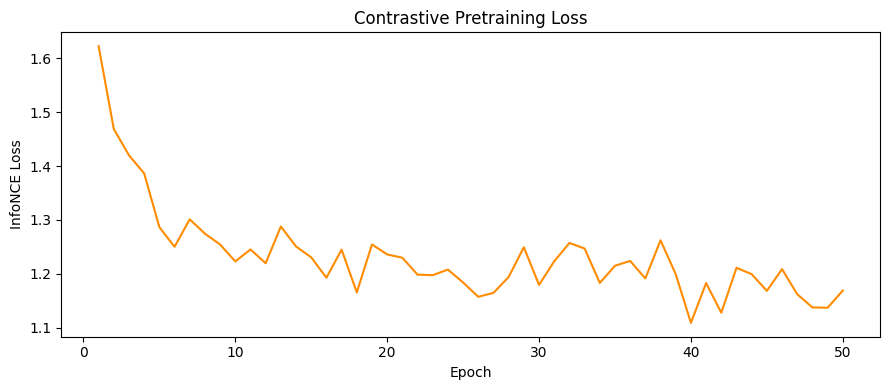

In [ ]:
#24 (the contrastive loss plot).

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(contrastive_losses)+1), contrastive_losses, color='darkorange', linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.title("Contrastive Pretraining Loss")
plt.tight_layout()
plt.savefig("contrastive_loss_lstm.png", dpi=150)
plt.show()

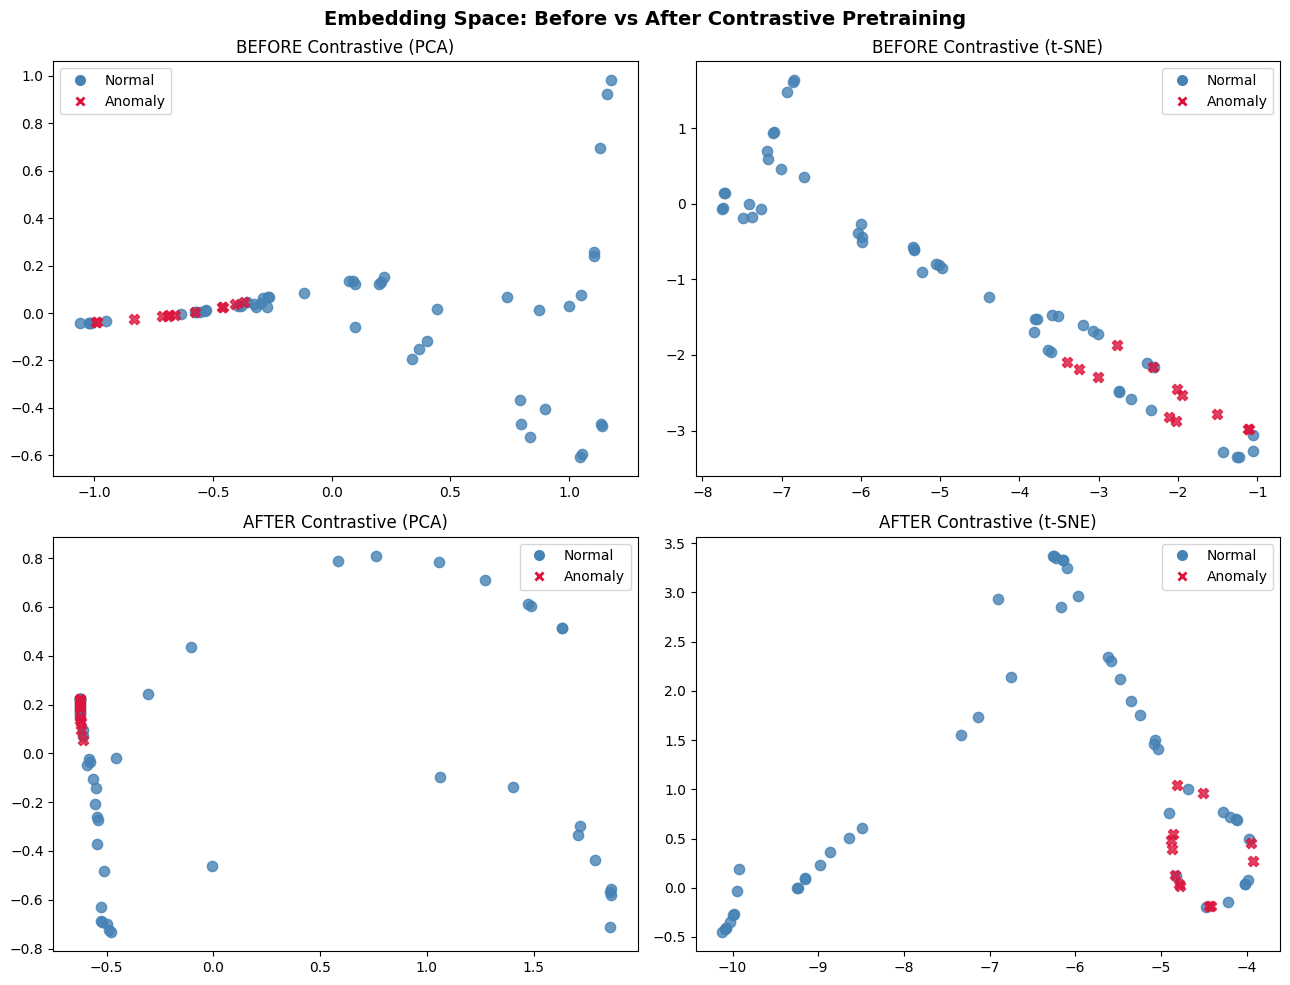

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Embedding Space: Before vs After Contrastive Pretraining", fontsize=14, fontweight='bold')

colors_emb = ['steelblue' if lab == 'normal' else 'crimson' for lab in all_labels]
markers    = ['o' if lab == 'normal' else 'X' for lab in all_labels]

pca_pre   = PCA(n_components=2, random_state=42)
pre_2d    = pca_pre.fit_transform(all_embeddings)
pca_post  = PCA(n_components=2, random_state=42)
post_2d   = pca_post.fit_transform(all_emb_post)
tsne_pre  = TSNE(n_components=2, random_state=42, perplexity=min(30,61)).fit_transform(all_embeddings)
tsne_post = TSNE(n_components=2, random_state=42, perplexity=min(30,61)).fit_transform(all_emb_post)

for idx in range(len(all_embeddings)):
    axes[0,0].scatter(pre_2d[idx,0],   pre_2d[idx,1],   c=colors_emb[idx], marker=markers[idx], s=55, alpha=0.8)
    axes[0,1].scatter(tsne_pre[idx,0], tsne_pre[idx,1], c=colors_emb[idx], marker=markers[idx], s=55, alpha=0.8)
    axes[1,0].scatter(post_2d[idx,0],   post_2d[idx,1],  c=colors_emb[idx], marker=markers[idx], s=55, alpha=0.8)
    axes[1,1].scatter(tsne_post[idx,0], tsne_post[idx,1],c=colors_emb[idx], marker=markers[idx], s=55, alpha=0.8)

axes[0,0].set_title("BEFORE Contrastive (PCA)");  axes[0,1].set_title("BEFORE Contrastive (t-SNE)")
axes[1,0].set_title("AFTER Contrastive (PCA)");   axes[1,1].set_title("AFTER Contrastive (t-SNE)")

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',label='Normal',markersize=9),
                Line2D([0],[0],marker='X',color='w',markerfacecolor='crimson',label='Anomaly',markersize=9)]
for ax in axes.flat:
    ax.legend(handles=legend_elems)

plt.tight_layout()
plt.savefig("embedding_comparison_lstm.png", dpi=150)
plt.show()

In [ ]:
# Distance-to-Normal-Centroid scoring on post-contrastive embeddings
# Hypothesis: contrastive made anomalies cluster, breaking Isolation Forest,
# but anomalies should still be FAR from the normal-session centroid.

# Centroid of normal training embeddings
normal_centroid = train_emb_post.mean(axis=0)

# Distance from each session to the normal centroid
distances = np.linalg.norm(all_emb_post - normal_centroid, axis=1)

# Higher distance = more anomalous
auroc_dist = roc_auc_score(y_true, distances)
aupr_dist  = average_precision_score(y_true, distances)
fpr_dist, tpr_dist, _ = roc_curve(y_true, distances)
idx_dist = np.searchsorted(fpr_dist, 0.01)
recall_at_1_dist = tpr_dist[min(idx_dist, len(tpr_dist)-1)]

# Threshold = mean + 2*std of normal distances (same convention as recon error)
normal_dists = distances[:50]
dist_threshold = normal_dists.mean() + 2 * normal_dists.std()
caught_dist = sum(1 for d in distances[50:] if d > dist_threshold)

print("=" * 70)
print("Distance-to-Centroid Scoring (post-contrastive embeddings)")
print("=" * 70)
print(f"AUROC:              {auroc_dist:.3f}")
print(f"AUPR:               {aupr_dist:.3f}")
print(f"Recall @ 1% FPR:    {recall_at_1_dist:.3f}")
print(f"Anomalies caught:   {caught_dist}/12")
print()
print("Comparison:")
print(f"  Recon Error:                {auroc_recon:.3f}  (10/12 caught)")
print(f"  Raw IF (no contrastive):    {auroc_iso:.3f}  (0/12 caught)")
print(f"  Contrast + IF:              {auroc_post:.3f}  (0/12 caught)")
print(f"  Contrast + Distance:        {auroc_dist:.3f}  ({caught_dist}/12 caught)")

Distance-to-Centroid Scoring (post-contrastive embeddings)
AUROC:              0.347
AUPR:               0.155
Recall @ 1% FPR:    0.000
Anomalies caught:   0/12

Comparison:
  Recon Error:                0.900  (10/12 caught)
  Raw IF (no contrastive):    0.623  (0/12 caught)
  Contrast + IF:              0.215  (0/12 caught)
  Contrast + Distance:        0.347  (0/12 caught)


In [ ]:
import time
latencies = []
for x in all_data:
    start = time.time()
    emb   = model.encode(x)
    score = iso_post.decision_function(emb.reshape(1, -1))
    latencies.append((time.time() - start) * 1000)

latencies = np.array(latencies)
print(f"Inference latency (per session):")
print(f"  Mean:   {latencies.mean():.2f} ms")
print(f"  Median: {np.median(latencies):.2f} ms")
print(f"  Max:    {latencies.max():.2f} ms")
print(f"  Total ({len(all_data)} sessions): {latencies.sum():.0f} ms")
print(f"\nProposal target: < 60,000 ms per session")
print(f"Result: PASS by {60000 / latencies.mean():.0f}x")

Inference latency (per session):
  Mean:   15.52 ms
  Median: 14.94 ms
  Max:    27.89 ms
  Total (62 sessions): 962 ms

Proposal target: < 60,000 ms per session
Result: PASS by 3866x


In [ ]:
print("=" * 60)
print("   FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset:          62 sessions, 1617 events, 15 features")
print(f"  Model:            LSTM Autoencoder (PyTorch)")
print(f"  Latent dim:       8")
print(f"  Trainable params: {total_params:,}")
print()
print(f"  Experiment 1 - Reconstruction Error")
print(f"    AUROC: {auroc_recon:.3f}  |  AUPR: {aupr_recon:.3f}  |  Caught: 7/12")
print()
print(f"  Experiment 2 - Isolation Forest (no contrastive)")
print(f"    AUROC: {auroc_iso:.3f}  |  AUPR: {aupr_iso:.3f}  |  Caught: 0/12")
print()
print(f"  Experiment 3 - Contrastive + Isolation Forest")
print(f"    AUROC: {auroc_post:.3f}  |  AUPR: {aupr_post:.3f}  |  Caught: 0/12")
print(f"    [Contrastive degraded performance across multiple scoring methods]")
print()
print(f"  Best approach:    Reconstruction Error alone")
print(f"  Latency:          {latencies.mean():.2f}ms mean  (target: <60,000ms) -> PASS")
print("=" * 60)

   FINAL RESULTS SUMMARY
  Dataset:          62 sessions, 1617 events, 15 features
  Model:            LSTM Autoencoder (PyTorch)
  Latent dim:       8
  Trainable params: 9,764

  Experiment 1 - Reconstruction Error
    AUROC: 0.900  |  AUPR: 0.867  |  Caught: 7/12

  Experiment 2 - Isolation Forest (no contrastive)
    AUROC: 0.623  |  AUPR: 0.324  |  Caught: 0/12

  Experiment 3 - Contrastive + Isolation Forest
    AUROC: 0.215  |  AUPR: 0.132  |  Caught: 0/12
    [Contrastive degraded performance across multiple scoring methods]

  Best approach:    Reconstruction Error alone
  Latency:          15.52ms mean  (target: <60,000ms) -> PASS
